# Bước 3: Khám phá Dữ Liệu (Exploratory Data Analysis - EDA)

Mục tiêu của notebook này là hiểu rõ bản chất sự tương quan giữa cổ phiếu ngành thép (HPG, HSG) và thị trường chung (VNINDEX) trước khi đưa vào mô hình học máy.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

## 3.1 Nạp và Chẩn bị Dữ liệu cơ bản

Chúng ta sẽ đọc các file `_raw.csv` và gộp chúng lại với nhau dựa trên cột thời gian (`time`).

In [3]:
# Khai báo đường dẫn
project_root = os.path.dirname(os.path.dirname(os.getcwd())) # Assumes notebooks/exploratory/
data_dir = os.path.join(project_root, 'data', 'raw')

# Đọc dữ liệu
df_vnindex = pd.read_csv(os.path.join(data_dir, 'VNINDEX_raw.csv'))
df_hpg = pd.read_csv(os.path.join(data_dir, 'HPG_raw.csv'))
df_hsg = pd.read_csv(os.path.join(data_dir, 'HSG_raw.csv'))

# Chuyển đổi datetime
for df in [df_vnindex, df_hpg, df_hsg]:
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)

# Gộp cột 'close' và 'volume'
data = pd.DataFrame({
    'VNI': df_vnindex['close'],
    'HPG': df_hpg['close'],
    'HSG': df_hsg['close'],
    'VNI_Vol': df_vnindex['volume'],
    'HPG_Vol': df_hpg['volume'],
    'HSG_Vol': df_hsg['volume']
})

# Drop NA do lệch ngày (lễ tết, lỗi dữ liệu)
data.dropna(inplace=True)
data.head()

,VNI,HPG,HSG,VNI_Vol,HPG_Vol,HSG_Vol
time,,,,,,
2020-01-02 07:00:00,0.97,8.27,5.43,131523160,4232230,3283180
2020-01-03 07:00:00,0.97,8.32,5.30,149202550,7832210,3031450
2020-01-06 07:00:00,0.96,8.27,5.32,140978550,5371060,4757100
2020-01-07 07:00:00,0.96,8.17,5.26,130272030,4871220,2309430
2020-01-08 07:00:00,0.95,8.08,5.22,179374340,6421130,3644680


## 3.2 Phân tích Tỷ suất sinh lời (Daily Return)

**Góc nhìn Feynman**: Nếu bạn mua một miếng đất giá 100 đồng, hôm sau lên 105 đồng, bạn lãi 5%. Đó là Return. Cái chúng ta quan tâm không phải giá miếng đất đắt hay rẻ, mà là mỗi ngày nó giật lên giật xuống bao nhiêu phần trăm.

In [4]:
# Tính Daily Returns (%) - pct_change()
returns = data[['VNI', 'HPG', 'HSG']].pct_change().dropna() * 100

returns.head()

,VNI,HPG,HSG
time,,,
2020-01-03 07:00:00,0.000000,0.604595,-2.394107
2020-01-06 07:00:00,-1.030928,-0.600962,0.377358
2020-01-07 07:00:00,0.000000,-1.209190,-1.127820
2020-01-08 07:00:00,-1.041667,-1.101591,-0.760456
2020-01-09 07:00:00,1.052632,2.351485,2.873563


## 3.3 Trực quan hóa Diễn biến Giá (Line Plot)

Để so sánh giá, chúng ta nên chuẩn hóa mọi thứ về cùng một điểm xuất phát (ví dụ: chia cho giá đầu tiên và nhân 100).

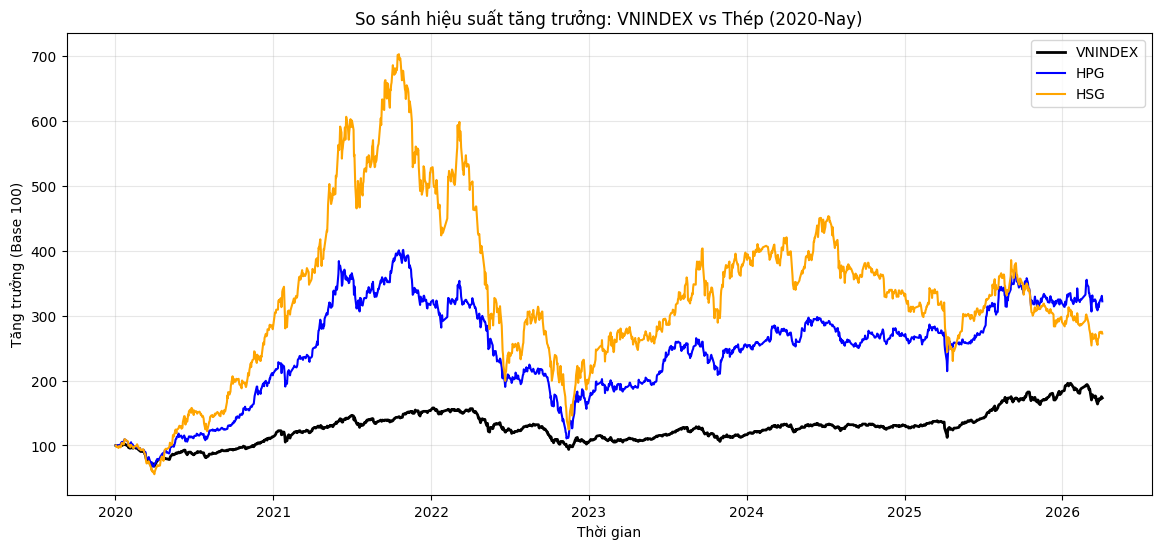

In [5]:
normalized_price = data[['VNI', 'HPG', 'HSG']] / data[['VNI', 'HPG', 'HSG']].iloc[0] * 100

plt.figure(figsize=(14, 6))
plt.plot(normalized_price.index, normalized_price['VNI'], label='VNINDEX', color='black', linewidth=2)
plt.plot(normalized_price.index, normalized_price['HPG'], label='HPG', color='blue')
plt.plot(normalized_price.index, normalized_price['HSG'], label='HSG', color='orange')

plt.title('So sánh hiệu suất tăng trưởng: VNINDEX vs Thép (2020-Nay)')
plt.ylabel('Tăng trưởng (Base 100)')
plt.xlabel('Thời gian')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3.4 Hiểu về Độ nhạy "Beta" qua Biểu đồ phân tán (Scatter Plot)

**Góc nhìn Feynman về Trục X và Trục Y:**
*   Hãy tưởng tượng **Trục X (VNINDEX)** ngang là một chiếc cân thăng bằng của thị trường. Cứ rớt sang trái là thị trường âm (-%), rẽ phải là dương (+%).
*   **Trục Y (HSG/HPG)** đứng là phản ứng của cổ phiếu Thép.
*   Mỗi một dấu chấm trên hình là một ngày giao dịch. Nếu tôi thả một dấu chấm ở tọa độ X = 1% và Y = 2%, nghĩa là hôm đó thị trường tăng 1% nhưng thép hưng phấn lên tận 2%.

**Vậy Beta là gì?**
Beta chính thức là **độ dốc (Slope)** của cái đám chấm kia, hay còn gọi là đường hồi quy (đường thằng đỏ vẽ xuyên qua tâm đám chấm).
*   Nếu độ dốc = 1 (Góc 45 độ): Thị trường hắt hơi, bạn cũng hắt hơi.
*   Nếu độ dốc > 1 (Đường dốc đứng hơn 45 độ): Thị trường hắt hơi nhẹ 1 cái, Thép hắt hơi 2 cái... Đó là **Rủi ro cao nhưng Lợi nhuận lớn** (High Beta). Cổ phiếu vật liệu chu kỳ như Thép thường có đặc tính này.

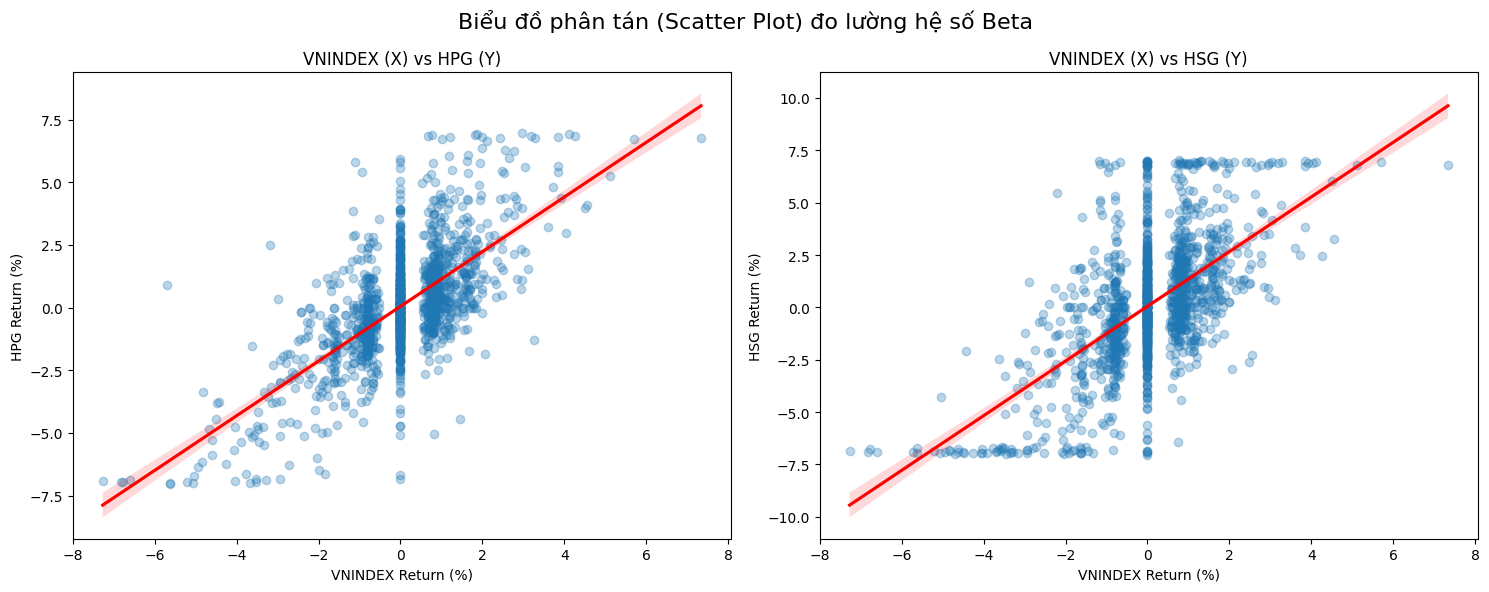

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# VNINDEX vs HPG
sns.regplot(x='VNI', y='HPG', data=returns, ax=axes[0], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
axes[0].set_title('VNINDEX (X) vs HPG (Y)')
axes[0].set_xlabel('VNINDEX Return (%)')
axes[0].set_ylabel('HPG Return (%)')

# VNINDEX vs HSG
sns.regplot(x='VNI', y='HSG', data=returns, ax=axes[1], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
axes[1].set_title('VNINDEX (X) vs HSG (Y)')
axes[1].set_xlabel('VNINDEX Return (%)')
axes[1].set_ylabel('HSG Return (%)')

plt.suptitle('Biểu đồ phân tán (Scatter Plot) đo lường hệ số Beta', fontsize=16)
plt.tight_layout()
plt.show()

**Insight**: Đường line đỏ dốc mạnh hơn góc 45 độ (y=x) chứng tỏ HPG và HSG đều có Beta > 1. HSG dường như có độ phân tán rộng hơn (rủi ro rung lắc cao hơn HPG).

## 3.5 Bản đồ nhiệt Tương quan (Heatmap)
Ai thường đi cùng ai? Bản đồ này giúp nhìn thẳng vào hệ số tương quan (chạy từ -1 đến 1).

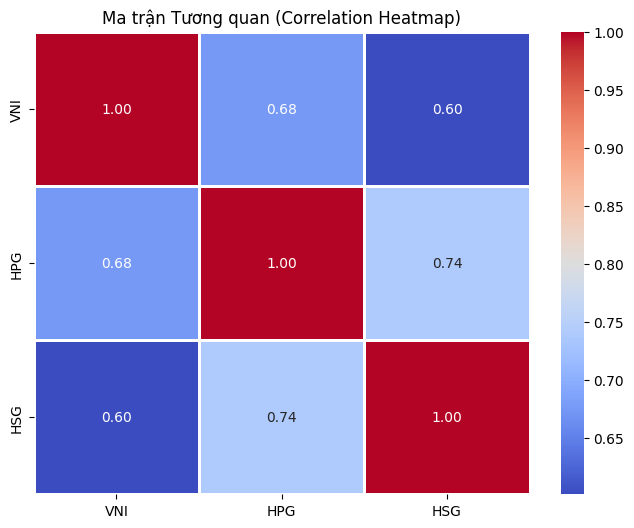

In [7]:
plt.figure(figsize=(8, 6))
corr_matrix = returns.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Ma trận Tương quan (Correlation Heatmap)')
plt.show()